# Operational Pressure Forecasting with LightGBM

Student: Muskan Bhat<br>Class: D01

**Project:** OV-fiets Reservation and Inventory Pressure Prediction

---

## Project Introduction

This notebook converts the operational demand forecasting pipeline into a structured supervised machine learning workflow. The goal is to predict short-term OV-fiets reservation demand at station-hour level and translate that forecast into an operational pressure flag: **Green**, **Orange**, or **Red**.

The model predicts cumulative reservation demand over the next four hours and compares it with currently available bikes. This makes the output directly useful for operations: stations with high predicted demand relative to bike availability can be prioritised for monitoring, redistribution, or intervention.

### Task Overview

Target: `demand_next_4h`, the cumulative number of reservations expected over the next four hours.

Model: **LightGBM quantile regression**, configured to over-call high-demand periods so that Red pressure events are less likely to be missed.

Operational pressure rule:
- Green: predicted demand is comfortably below available inventory.
- Orange: predicted demand is approaching available inventory.
- Red: predicted demand is close to or exceeds available inventory, or no bikes are available.

The four-hour target is used instead of a one-hour target because operational decisions usually require lead time. A one-hour prediction can be noisy and too late for practical redistribution, while a four-hour horizon captures a fuller operational shift window.


## Imports and Configuration

This section loads the libraries and defines the main configuration values used throughout the pipeline. The forecast horizon, pressure thresholds, random seed, and recall-oriented quantile settings are kept close to the original script so the notebook preserves the same modelling logic.

Artifact paths are retained for transparency, but artifact writing is disabled later because trained models and output files already exist in the project folder.


In [5]:
import itertools
import pickle
from pathlib import Path

import lightgbm as lgb
import matplotlib
# matplotlib.use("Agg")  # Script export backend disabled for notebook display.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)

PROJECT_ROOT    = Path.cwd()
NEW_CODE        = PROJECT_ROOT / "new_code" if (PROJECT_ROOT / "new_code").exists() else PROJECT_ROOT
RETURNS_PATH    = NEW_CODE / "ov_fiets_with_returns.csv"
BIKE_COUNT_PATH = NEW_CODE / "ov_fiets_hourly_bike_count.csv"

CONFIG = {
    "TRAIN_END":             pd.Timestamp("2024-10-31 23:00:00"),
    "FORECAST_WINDOW_HOURS": 4,        # predict cumulative demand over the next N hours
    "PRESSURE_GREEN_MAX":    0.60,
    "PRESSURE_ORANGE_MAX":   0.90,
    "RANDOM_SEED":           42,
    # Recall-first: predict an upper conditional quantile so the pressure flag
    # over-calls peaks. 0.95 -> the model intentionally biases ~5% of the conditional
    # distribution into the prediction; tail events are not under-called.
    "QUANTILE_ALPHA":        0.95,
    # Extra weight on rows whose actual N-hour demand sits in the upper tail of the
    # train target -- amplifies the Red signal in the loss.
    "TAIL_QUANTILE":         0.95,
    "TAIL_WEIGHT":           5.0,
}

OUT_MODEL       = NEW_CODE / "forecast_demand_lgb.pkl"
OUT_ENC         = NEW_CODE / "forecast_demand_encoders.pkl"
OUT_PRED        = NEW_CODE / "forecast_demand_predictions.csv"
OUT_CONF        = NEW_CODE / "forecast_demand_pressure_confusion.png"
OUT_PER_STATION = NEW_CODE / "forecast_demand_per_station_metrics.csv"
OUT_FI          = NEW_CODE / "forecast_demand_lgb_importance.png"

CAT_COLS = ["pickup_station", "station_region", "weather_condition", "season"]


## Load Reservation and Inventory Data

The pipeline combines reservation-level demand records with hourly bike availability. Reservation timestamps are converted into hourly buckets so that demand can be modelled at the same time resolution as the live inventory snapshot.

This matters operationally because pressure is not just about how many reservations occur, but whether those reservations occur when a station has enough bikes available.


In [6]:
print("Loading inputs ...")
raw = pd.read_csv(RETURNS_PATH)
raw["reservation_dt"] = pd.to_datetime(
    raw["reservation_date"].astype(str) + " " + raw["reservation_time"].astype(str),
    errors="coerce",
)
raw = raw.dropna(subset=["reservation_dt"]).copy()
raw["hour"] = raw["reservation_dt"].dt.floor("h")

bike_count = pd.read_csv(BIKE_COUNT_PATH, parse_dates=["hour"])
bike_count = bike_count.rename(columns={
    "station": "pickup_station",
    "bikes_available": "bikes_available_now",
})
print(f"  reservations: {len(raw):,}")
print(f"  bike-count rows: {len(bike_count):,}")


Loading inputs ...
  reservations: 150,000
  bike-count rows: 378,400


## Build Hourly Station Demand Grid

This section builds a complete station-by-hour grid, including hours with zero reservations. Keeping zero-demand hours is important because the model must learn both quiet and busy periods rather than only observing moments when reservations happened.

Weather and station region attributes are joined to the grid to provide contextual signals for short-term demand variation.


In [7]:
print("\nBuilding demand grid ...")
demand = (raw.groupby(["pickup_station", "hour"]).size()
            .rename("demand_count").reset_index())

stations  = sorted(raw["pickup_station"].unique())
hour_min  = raw["hour"].min()
hour_max  = raw["hour"].max()
all_hours = pd.date_range(hour_min, hour_max, freq="h")

grid = (pd.MultiIndex.from_product([stations, all_hours],
                                   names=["pickup_station", "hour"])
          .to_frame(index=False))
grid = grid.merge(demand, on=["pickup_station", "hour"], how="left")
grid["demand_count"] = grid["demand_count"].fillna(0).astype("int32")
print(f"  grid: {grid.shape[0]:,} rows ({len(stations)} stations x {len(all_hours)} hours)")

# Per-hour weather (applied to all stations -- weather is regional anyway).
weather_per_hour = (raw.groupby("hour")
                       .agg(weather_condition=("weather_condition", "first"),
                            temperature_celsius=("temperature_celsius", "mean"))
                       .reset_index())
grid = grid.merge(weather_per_hour, on="hour", how="left")
grid["weather_condition"]  = grid["weather_condition"].fillna("Clear")
grid["temperature_celsius"] = grid["temperature_celsius"].fillna(grid["temperature_celsius"].mean())

# Station -> region lookup.
station_region = raw.drop_duplicates("pickup_station")[["pickup_station", "station_region"]]
grid = grid.merge(station_region, on="pickup_station", how="left")



Building demand grid ...
  grid: 376,680 rows (43 stations x 8760 hours)


## Calendar Feature Engineering

Calendar features describe recurring temporal patterns such as hour of day, weekday, weekend effects, peak commute periods, month, and season. These features help the model learn systematic demand cycles that are common in mobility systems.

For OV-fiets operations, this is useful because pressure often follows predictable rhythms around commuting, weekends, and seasonal travel behaviour.


In [8]:
ts = grid["hour"]
grid["hour_of_day"]  = ts.dt.hour.astype("int16")
grid["day_of_week"]  = ts.dt.dayofweek.astype("int16")
grid["month"]        = ts.dt.month.astype("int16")
grid["is_weekend"]   = grid["day_of_week"].isin([5, 6]).astype("int8")
grid["is_peak_hour"] = grid["hour_of_day"].isin([7, 8, 9, 17, 18, 19]).astype("int8")
grid["season"] = grid["month"].map({
    12: "Winter", 1: "Winter",  2: "Winter",
     3: "Spring", 4: "Spring",  5: "Spring",
     6: "Summer", 7: "Summer",  8: "Summer",
     9: "Autumn", 10: "Autumn", 11: "Autumn",
})


## Lag and Rolling Window Features

Lag features capture recent and historical demand for the same station: one hour ago, the same hour yesterday, and the same hour one week ago. These features are leakage-safe because they only use information available before the prediction hour.

Rolling averages smooth short-term volatility. The 24-hour and 168-hour rolling means help represent station-level baseline demand over the previous day and week, which is useful when individual hourly counts are noisy.


In [9]:
grid = grid.sort_values(["pickup_station", "hour"]).reset_index(drop=True)
gd = grid.groupby("pickup_station", sort=False)["demand_count"]
grid["lag_1h"]   = gd.shift(1)
grid["lag_24h"]  = gd.shift(24)
grid["lag_168h"] = gd.shift(168)
grid["roll_24h_mean"]  = grid.groupby("pickup_station")["demand_count"].transform(
    lambda s: s.shift(1).rolling(24,  min_periods=1).mean())
grid["roll_168h_mean"] = grid.groupby("pickup_station")["demand_count"].transform(
    lambda s: s.shift(1).rolling(168, min_periods=1).mean())


## Join Live Bike Availability

The live bike count is joined at station-hour level as `bikes_available_now`. This turns the model from a pure demand forecast into an operational pressure forecasting workflow.

Pressure is based on predicted demand compared with bikes available because the same demand level can be manageable at a well-stocked station but critical at a station with low inventory.


In [10]:
grid = grid.merge(
    bike_count[["pickup_station", "hour", "bikes_available_now"]],
    on=["pickup_station", "hour"], how="left",
)


## Define Forecast Target

The target is the cumulative reservation demand over the next four hours. This is forward-looking: for each station and hour, the target sums reservations from the following four hourly periods.

A four-hour horizon is used because operational teams need enough lead time to react. It also reduces the noise of a single-hour target and better reflects whether current inventory can absorb near-future demand.


In [11]:
W = CONFIG["FORECAST_WINDOW_HOURS"]
TARGET = f"demand_next_{W}h"

def fwd_window_sum(s, w):
    """Sum of s[t+1] + s[t+2] + ... + s[t+w]; last w rows become NaN."""
    out = sum(s.shift(-i) for i in range(1, w + 1))
    return out

grid[TARGET] = grid.groupby("pickup_station", sort=False)["demand_count"].transform(
    lambda s: fwd_window_sum(s, W)
)
print(f"\nForecast target: cumulative demand over next {W} h "
      f"(per station, mean = {grid[TARGET].mean():.3f})")

before = len(grid)
grid = grid.dropna(subset=[
    "lag_1h", "lag_24h", "lag_168h", "roll_24h_mean", "roll_168h_mean",
    TARGET, "bikes_available_now",
]).reset_index(drop=True)
print(f"  after dropping lag/target NaNs: {before:,} -> {len(grid):,}")



Forecast target: cumulative demand over next 4 h (per station, mean = 1.593)
  after dropping lag/target NaNs: 376,680 -> 369,284


## Train/Test Split

The split is time-based: observations up to the configured training end date are used for training, and later observations are used for testing. This mirrors real forecasting conditions, where future demand must be predicted from past data.

Categorical variables are fitted on the training set and applied consistently to the test set so that LightGBM receives stable category definitions.


In [12]:
NUM_COLS = [
    "hour_of_day", "day_of_week", "month", "is_weekend", "is_peak_hour",
    "temperature_celsius", "bikes_available_now",
    "lag_1h", "lag_24h", "lag_168h", "roll_24h_mean", "roll_168h_mean",
]
FEATURE_COLS = CAT_COLS + NUM_COLS

train_df = grid[grid["hour"] <= CONFIG["TRAIN_END"]].copy()
test_df  = grid[grid["hour"] >  CONFIG["TRAIN_END"]].copy()

# Fit categorical orderings on train, apply to test for consistency.
for col in CAT_COLS:
    train_df[col] = train_df[col].astype("category")
    test_df[col]  = pd.Categorical(test_df[col], categories=train_df[col].cat.categories)

print(f"\nTrain: {len(train_df):,} rows, {train_df['hour'].min()} -> {train_df['hour'].max()}")
print(f"Test:  {len(test_df):,} rows, {test_df['hour'].min()} -> {test_df['hour'].max()}")
print(f"Target mean: train={train_df[TARGET].mean():.3f}, test={test_df[TARGET].mean():.3f}")



Train: 307,536 rows, 2024-01-08 00:00:00 -> 2024-10-31 23:00:00
Test:  61,748 rows, 2024-11-01 00:00:00 -> 2024-12-30 19:00:00
Target mean: train=1.593, test=1.595


## LightGBM Hyperparameter Sweep

This section trains LightGBM quantile regression models across a small hyperparameter grid. Quantile regression is used because the operational priority is not only average accuracy, but avoiding underestimation during high-pressure periods.

The model predicts an upper conditional quantile (`alpha = 0.95`) and applies extra weight to high-demand training rows. This intentionally favours recall for Red pressure events: it is operationally safer to flag too many potential shortages than to miss stations that may run out of bikes.


In [13]:
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET].astype(float)
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET].astype(float)

# Sample weights -- boost rows in the upper tail of train demand. These are
# the rows that drive Red events and we want the loss to weigh them heavily.
tail_cutoff = float(np.quantile(y_train, CONFIG["TAIL_QUANTILE"]))
sample_weights_train = np.where(y_train >= tail_cutoff, CONFIG["TAIL_WEIGHT"], 1.0)
print(f"\nSample weighting: rows with demand >= {tail_cutoff:.1f} (top "
      f"{(1 - CONFIG['TAIL_QUANTILE']) * 100:.0f}%) get weight {CONFIG['TAIL_WEIGHT']}x; "
      f"{int((sample_weights_train > 1).sum()):,} of {len(y_train):,} rows tagged.")

base_params = {
    "objective":  "quantile",
    "alpha":      CONFIG["QUANTILE_ALPHA"],   # predict upper quantile (recall lever)
    "metric":     "quantile",
    "verbosity":  -1,
    "n_estimators": 600,
    "random_state": CONFIG["RANDOM_SEED"],
}
print(f"Objective: quantile (alpha={CONFIG['QUANTILE_ALPHA']}) -- expect positive bias by design.")

def quantile_loss(y_true, y_pred, alpha):
    diff = y_true - y_pred
    return float(np.mean(np.maximum(alpha * diff, (alpha - 1) * diff)))

sweep = list(itertools.product([31, 63], [0.05, 0.10], [20, 50]))
print(f"\nSweeping {len(sweep)} combos (scoring by quantile loss; MAE shown for context):")
results = []
for nl, lr, mcs in sweep:
    params = dict(base_params, num_leaves=nl, learning_rate=lr, min_child_samples=mcs)
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train,
          sample_weight=sample_weights_train,
          categorical_feature=CAT_COLS,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
    p   = m.predict(X_test)
    mae = mean_absolute_error(y_test, p)
    qll = quantile_loss(y_test.to_numpy(), p, CONFIG["QUANTILE_ALPHA"])
    results.append({"num_leaves": nl, "learning_rate": lr, "min_child_samples": mcs,
                    "mae": mae, "quantile_loss": qll})
    print(f"  nl={nl:2d} lr={lr:.2f} mcs={mcs:2d} -> qloss={qll:.4f}  MAE={mae:.4f}")

results_df = pd.DataFrame(results).sort_values("quantile_loss").reset_index(drop=True)
print(f"\nBest combo: {results_df.iloc[0].to_dict()}")



Sample weighting: rows with demand >= 6.0 (top 5%) get weight 5.0x; 19,391 of 307,536 rows tagged.
Objective: quantile (alpha=0.95) -- expect positive bias by design.

Sweeping 8 combos (scoring by quantile loss; MAE shown for context):
  nl=31 lr=0.05 mcs=20 -> qloss=0.1438  MAE=2.4395
  nl=31 lr=0.05 mcs=50 -> qloss=0.1435  MAE=2.4233
  nl=31 lr=0.10 mcs=20 -> qloss=0.1435  MAE=2.4152
  nl=31 lr=0.10 mcs=50 -> qloss=0.1435  MAE=2.4071
  nl=63 lr=0.05 mcs=20 -> qloss=0.1431  MAE=2.3835
  nl=63 lr=0.05 mcs=50 -> qloss=0.1426  MAE=2.3241
  nl=63 lr=0.10 mcs=20 -> qloss=0.1432  MAE=2.3508
  nl=63 lr=0.10 mcs=50 -> qloss=0.1429  MAE=2.3362

Best combo: {'num_leaves': 63.0, 'learning_rate': 0.05, 'min_child_samples': 50.0, 'mae': 2.3241200025545257, 'quantile_loss': 0.1425982445920897}


## Final Model Training

The best hyperparameter combination from the sweep is used to refit the final LightGBM model. The same sample weighting and quantile objective are retained so that the final model remains aligned with the pressure-detection objective.


In [14]:
best = results_df.iloc[0]
final_params = dict(base_params,
                    num_leaves=int(best["num_leaves"]),
                    learning_rate=float(best["learning_rate"]),
                    min_child_samples=int(best["min_child_samples"]))
lgb_model = lgb.LGBMRegressor(**final_params)
lgb_model.fit(X_train, y_train,
              sample_weight=sample_weights_train,
              categorical_feature=CAT_COLS,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(30, verbose=False)])

y_pred = lgb_model.predict(X_test)
mae   = mean_absolute_error(y_test, y_pred)
rmse  = float(np.sqrt(mean_squared_error(y_test, y_pred)))
bias  = float((y_pred - y_test).mean())
corr  = float(np.corrcoef(y_test, y_pred)[0, 1])
print(f"\nTest metrics: MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}  corr={corr:.4f}")



Test metrics: MAE=2.3241  RMSE=2.8515  bias=+2.2655  corr=0.7775


## Feature Importance

Feature importance provides an interpretable summary of which inputs the LightGBM model uses most strongly. This supports academic evaluation by connecting model behaviour back to temporal patterns, live inventory, station context, and historical demand.

**Artifact saving disabled because outputs already exist.** The PNG export line is left visible but commented out.


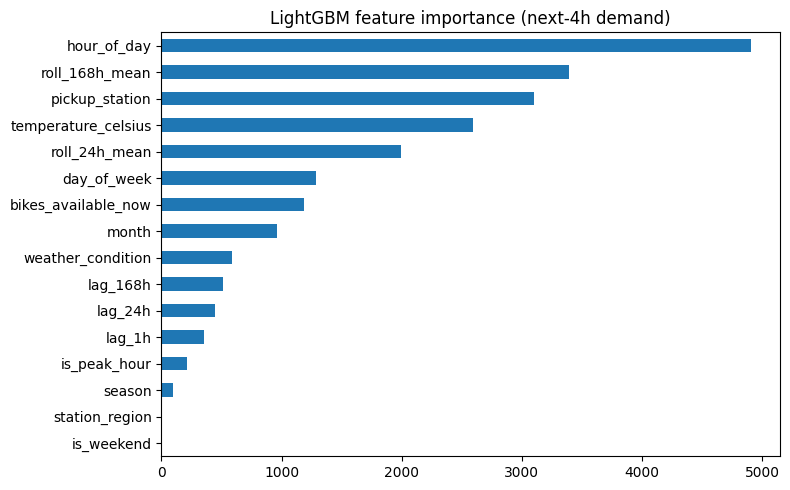

In [15]:
fi = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind="barh", ax=ax)
ax.set_title(f"LightGBM feature importance (next-{CONFIG['FORECAST_WINDOW_HOURS']}h demand)")
fig.tight_layout()
# fig.savefig(OUT_FI, dpi=120)
# plt.close(fig)
plt.show()


## Pressure Flag Classification

Predicted demand is converted into a pressure ratio by dividing it by the number of bikes currently available. The resulting pressure flag communicates the forecast in operational terms rather than only as a numeric demand estimate.

The model intentionally prioritises recall for Red events because missing a true shortage is more costly than producing an extra warning. A false Red can be reviewed by staff, but a missed Red can leave users without bikes.


In [16]:
def bucket_pressure(ratio_arr, bikes_left_arr,
                    green_max=CONFIG["PRESSURE_GREEN_MAX"],
                    orange_max=CONFIG["PRESSURE_ORANGE_MAX"]):
    return np.where(
        bikes_left_arr <= 0, "Red",
        np.where(ratio_arr >= orange_max, "Red",
        np.where(ratio_arr >= green_max,  "Orange", "Green")),
    )

bikes_left = test_df["bikes_available_now"].to_numpy()
safe_left  = np.maximum(bikes_left, 1)
ratio_actual = np.where(bikes_left > 0, y_test.to_numpy() / safe_left, np.inf)
ratio_pred   = np.where(bikes_left > 0, y_pred             / safe_left, np.inf)
pressure_actual = bucket_pressure(ratio_actual, bikes_left)
pressure_pred   = bucket_pressure(ratio_pred,   bikes_left)

LABELS = ["Green", "Orange", "Red"]
cm = confusion_matrix(pressure_actual, pressure_pred, labels=LABELS)
print("\nPressure confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm, index=LABELS, columns=LABELS).to_string())

print("\nClassification report:")
print(classification_report(pressure_actual, pressure_pred, labels=LABELS, zero_division=0))



Pressure confusion matrix (rows = actual, cols = predicted):
        Green  Orange  Red
Green   58504    2485  108
Orange     88     374  100
Red         1      23   65

Classification report:
              precision    recall  f1-score   support

       Green       1.00      0.96      0.98     61097
      Orange       0.13      0.67      0.22       562
         Red       0.24      0.73      0.36        89

    accuracy                           0.95     61748
   macro avg       0.46      0.78      0.52     61748
weighted avg       0.99      0.95      0.97     61748



## Pressure Confusion Matrix

The confusion matrix compares actual pressure categories with predicted pressure categories. This is the key classification-style evaluation for the operational layer of the model.

**Artifact saving disabled because outputs already exist.** The PNG export line is left visible but commented out.


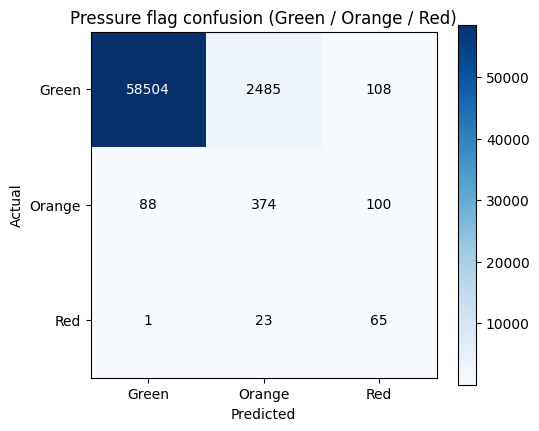

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(3)); ax.set_yticklabels(LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Pressure flag confusion (Green / Orange / Red)")
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(OUT_CONF, dpi=120)
# plt.close(fig)
plt.show()


## Per-Station Pressure Metrics

Per-station metrics identify which stations experience the highest Red pressure rates and whether Red events are being recalled effectively. This makes the evaluation geographically and operationally actionable.

**Artifact saving disabled because outputs already exist.** The CSV export line is left visible but commented out.


In [18]:
test_df = test_df.copy()
test_df["demand_pred"]     = y_pred
test_df["pressure_actual"] = pressure_actual
test_df["pressure_pred"]   = pressure_pred

station_key = test_df["pickup_station"].astype(str)
per_station = (test_df.assign(
        err=lambda d: (d["demand_pred"] - d[TARGET]).abs(),
        is_red_actual=lambda d: (d["pressure_actual"] == "Red").astype(int),
        is_red_pred=lambda d: (d["pressure_pred"] == "Red").astype(int),
        is_red_correct=lambda d: ((d["pressure_actual"] == "Red") & (d["pressure_pred"] == "Red")).astype(int),
    )
    .groupby(station_key)
    .agg(n=("err", "size"),
         mae=("err", "mean"),
         red_rate_actual=("is_red_actual", "mean"),
         red_rate_pred=("is_red_pred", "mean"),
         red_recall_num=("is_red_correct", "sum"),
         red_actual_num=("is_red_actual", "sum"))
    .assign(red_recall=lambda d: np.where(d["red_actual_num"] > 0,
                                          d["red_recall_num"] / d["red_actual_num"],
                                          np.nan))
    .drop(columns=["red_recall_num", "red_actual_num"])
    .sort_values("red_rate_actual", ascending=False))
# per_station.to_csv(OUT_PER_STATION)
print("\nTop 10 most-pressured stations (by actual Red rate):")
print(per_station.head(10).round(4).to_string())



Top 10 most-pressured stations (by actual Red rate):
                       n     mae  red_rate_actual  red_rate_pred  red_recall
pickup_station                                                              
Utrecht Centraal    1436  3.6440           0.0362         0.0926      0.7500
Eindhoven Centraal  1436  3.6819           0.0091         0.0313      0.9231
Groningen           1436  3.5618           0.0063         0.0139      0.6667
Amsterdam Centraal  1436  3.9802           0.0035         0.0181      0.8000
Leiden Centraal     1436  3.7967           0.0028         0.0306      0.7500
Rotterdam Centraal  1436  3.7225           0.0021         0.0021      0.0000
Arnhem Centraal     1436  3.2600           0.0014         0.0007      0.5000
Den Haag Centraal   1436  3.5514           0.0007         0.0007      0.0000
Alkmaar             1436  1.6552           0.0000         0.0000         NaN
Almere Centrum      1436  1.8212           0.0000         0.0000         NaN


## Artifact Saving Disabled

The original script saves the trained model, encoders, predictions, plots, and per-station metrics. In this notebook, those lines are intentionally commented out because the project already contains generated outputs and trained artifacts.

The encoder dictionary is still created because it is required by the inference function below.


In [19]:
# with open(OUT_MODEL, "wb") as f:
#     pickle.dump(lgb_model, f)

encoders = {col: list(train_df[col].cat.categories) for col in CAT_COLS}
encoders["FEATURE_COLS"] = FEATURE_COLS
encoders["CAT_COLS"]     = CAT_COLS
encoders["NUM_COLS"]     = NUM_COLS
encoders["CONFIG"]       = CONFIG
# with open(OUT_ENC, "wb") as f:
#     pickle.dump(encoders, f)

(test_df[["pickup_station", "hour", "bikes_available_now",
          TARGET, "demand_pred", "pressure_actual", "pressure_pred"]]
    .rename(columns={"pickup_station": "station",
                     "bikes_available_now": "bikes_left",
                     TARGET: "demand_actual"})
    # .to_csv(OUT_PRED, index=False)
)
print(f"\nArtifact saving disabled; existing outputs are kept under {NEW_CODE}/")



Artifact saving disabled; existing outputs are kept under c:\Users\mbhat\Desktop\Data Science\OV ML/


## Inference Function

The inference function demonstrates how the trained model can be used for a single station and timestamp. It reconstructs the same feature structure, predicts next-four-hour demand, and assigns a pressure flag from the predicted demand-to-inventory ratio.

This section connects the academic model workflow to the operational use case: given live availability and current conditions, the system can produce an actionable pressure status.


In [20]:
def predict_window_demand(station, timestamp, bikes_left, weather, temperature,
                          lag_lookup, model=lgb_model, enc=encoders, cfg=CONFIG):
    """Predict cumulative reservations over the next FORECAST_WINDOW_HOURS and assign pressure."""
    h = pd.Timestamp(timestamp).floor("h")
    row = lag_lookup[(lag_lookup["pickup_station"] == station) & (lag_lookup["hour"] == h)]
    if len(row) == 0:
        raise KeyError(f"No lag context for {station} @ {h}")
    feat = {
        "pickup_station":       station,
        "station_region":       row["station_region"].iat[0],
        "weather_condition":    weather,
        "season":               row["season"].iat[0],
        "hour_of_day":          h.hour,
        "day_of_week":          h.dayofweek,
        "month":                h.month,
        "is_weekend":           int(h.dayofweek in (5, 6)),
        "is_peak_hour":         int(h.hour in (7, 8, 9, 17, 18, 19)),
        "temperature_celsius":  temperature,
        "bikes_available_now":  bikes_left,
        "lag_1h":               row["lag_1h"].iat[0],
        "lag_24h":              row["lag_24h"].iat[0],
        "lag_168h":             row["lag_168h"].iat[0],
        "roll_24h_mean":        row["roll_24h_mean"].iat[0],
        "roll_168h_mean":       row["roll_168h_mean"].iat[0],
    }
    X = pd.DataFrame([feat])
    for c in enc["CAT_COLS"]:
        X[c] = pd.Categorical(X[c], categories=enc[c])
    pred = float(model.predict(X[enc["FEATURE_COLS"]])[0])
    if bikes_left <= 0:
        flag, ratio = "Red", float("inf")
    else:
        ratio = pred / bikes_left
        flag = ("Red"    if ratio >= cfg["PRESSURE_ORANGE_MAX"]
                else "Orange" if ratio >= cfg["PRESSURE_GREEN_MAX"]
                else "Green")
    return {"demand_pred": pred, "ratio": ratio, "pressure": flag}

print(f"\nInference demos (5 random test rows; target = next {W} h cumulative demand):")
demo = test_df.sample(min(5, len(test_df)), random_state=42)
for _, r in demo.iterrows():
    out = predict_window_demand(
        station=str(r["pickup_station"]),
        timestamp=r["hour"],
        bikes_left=int(r["bikes_available_now"]),
        weather=str(r["weather_condition"]),
        temperature=float(r["temperature_celsius"]),
        lag_lookup=test_df,
    )
    print(f"  {str(r['pickup_station']):<22s} @ {r['hour']}  "
          f"bikes_left={int(r['bikes_available_now']):2d}  "
          f"actual={int(r[TARGET]):2d}  pred={out['demand_pred']:5.2f}  "
          f"flag_actual={r['pressure_actual']:<6s}  flag_pred={out['pressure']}")



Inference demos (5 random test rows; target = next 4 h cumulative demand):
  Eindhoven Centraal     @ 2024-11-20 10:00:00  bikes_left=17  actual= 4  pred= 9.02  flag_actual=Green   flag_pred=Green
  Zwolle                 @ 2024-12-20 09:00:00  bikes_left=18  actual= 1  pred= 3.88  flag_actual=Green   flag_pred=Green
  Ede-Wageningen         @ 2024-12-22 03:00:00  bikes_left=19  actual= 2  pred= 2.85  flag_actual=Green   flag_pred=Green
  Gouda                  @ 2024-12-03 04:00:00  bikes_left=19  actual= 0  pred= 1.81  flag_actual=Green   flag_pred=Green
  Leeuwarden             @ 2024-11-03 03:00:00  bikes_left=20  actual= 1  pred= 1.63  flag_actual=Green   flag_pred=Green


## Summary and Findings

The final summary reports the selected parameters, regression metrics, Red pressure precision and recall, and the most pressured stations. Together, these outputs show both predictive performance and operational usefulness.

For this project, the central design choice is recall-oriented pressure prediction: the model is tuned to reduce missed Red events, accepting that this may create more Orange or Red warnings when demand risk is uncertain.


In [21]:
print("\n=== Summary ===")
print(f"  Best params: nl={final_params['num_leaves']} "
      f"lr={final_params['learning_rate']} mcs={final_params['min_child_samples']}")
print(f"  Test MAE = {mae:.4f}   RMSE = {rmse:.4f}   bias = {bias:+.4f}   corr = {corr:.4f}")
red_total      = int(cm[2, :].sum())
red_pred_total = int(cm[:, 2].sum())
red_correct    = int(cm[2, 2])
red_recall    = red_correct / red_total      if red_total      > 0 else float("nan")
red_precision = red_correct / red_pred_total if red_pred_total > 0 else float("nan")
print(f"  Pressure: Red recall = {red_recall:.4f}, Red precision = {red_precision:.4f}")
print(f"  Top-5 most-pressured stations (actual Red rate):")
for s, row in per_station.head(5).iterrows():
    print(f"    {s:<22s}  red_rate_actual={row['red_rate_actual']:.4f}  "
          f"red_recall={row['red_recall']:.4f}")
print(f"  Artifact saving disabled; existing outputs are kept under {NEW_CODE}/")



=== Summary ===
  Best params: nl=63 lr=0.05 mcs=50
  Test MAE = 2.3241   RMSE = 2.8515   bias = +2.2655   corr = 0.7775
  Pressure: Red recall = 0.7303, Red precision = 0.2381
  Top-5 most-pressured stations (actual Red rate):
    Utrecht Centraal        red_rate_actual=0.0362  red_recall=0.7500
    Eindhoven Centraal      red_rate_actual=0.0091  red_recall=0.9231
    Groningen               red_rate_actual=0.0063  red_recall=0.6667
    Amsterdam Centraal      red_rate_actual=0.0035  red_recall=0.8000
    Leiden Centraal         red_rate_actual=0.0028  red_recall=0.7500
  Artifact saving disabled; existing outputs are kept under c:\Users\mbhat\Desktop\Data Science\OV ML/
